# WP3 — Partie 4 : Projection MLP avec le token CLS de MAE

Même pipeline que les parties 1-2-3, mais on utilise le **token CLS** de MAE (`last_hidden_state[:, 0]`) au lieu de la moyenne des patches (`z_full`).

**Hypothèse :** le token CLS agrège l'information globale de l'image et pourrait s'aligner plus facilement sur `z_clip` que la moyenne des patches.

## 4.1 Chargement MAE et CLIP

In [4]:
import os
import torch
import torch.nn.functional as F
from transformers import ViTImageProcessor, ViTMAEModel, CLIPProcessor, CLIPModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

MAE_PATH = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'
CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'

mae_processor = ViTImageProcessor.from_pretrained(MAE_PATH)
mae_encoder = ViTMAEModel.from_pretrained(MAE_PATH).to(DEVICE)
mae_encoder.eval()

clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
clip_model.eval()

MAE_DIM = mae_encoder.config.hidden_size
CLIP_DIM = clip_model.config.projection_dim
print(f'MAE dim  : {MAE_DIM}')
print(f'CLIP dim : {CLIP_DIM}')

Device : cpu


/Users/Ahmed/miniconda3/envs/torch/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


MAE dim  : 1024
CLIP dim : 768


## 4.2 Chargement dataset

In [2]:
from datasets import load_dataset
from torch.utils.data import Dataset
from torchvision import transforms
from huggingface_hub import snapshot_download

DATASET_DIR = './imagenet100-hf'
if not os.path.exists(f'{DATASET_DIR}/data'):
    print('Téléchargement ImageNet-100...')
    snapshot_download(repo_id='ilee0022/ImageNet100', repo_type='dataset', local_dir=DATASET_DIR)

transform_tensor = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

class ImageNet100Dataset(Dataset):
    def __init__(self, split, transform=None):
        pattern = f'{DATASET_DIR}/data/{split}-*.parquet'
        self.ds = load_dataset('parquet', data_files={split: pattern})[split]
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img = self.ds[idx]['image'].convert('RGB')
        label = self.ds[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label

dataset_train = ImageNet100Dataset('train', transform=transform_tensor)
dataset_val = ImageNet100Dataset('validation', transform=transform_tensor)
print(f'Train : {len(dataset_train)} images')
print(f'Val   : {len(dataset_val)} images')

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

Train : 117000 images
Val   : 13000 images


## 4.3 Génération des paires (z_cls, z_clip)

Seul changement par rapport à `wp3_1` : on prend `last_hidden_state[:, 0]` (token CLS) au lieu de `last_hidden_state[:, 1:].mean(dim=1)` (moyenne des patches).

In [6]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

def generate_pairs_cls(dataset, batch_size=64, desc=''):
    """
    Genere (z_cls, z_clip) pour chaque image.
    z_cls  : token CLS de MAE -> last_hidden_state[:, 0], dim 1024
    z_clip : embedding CLIP normalise L2, dim 768
    """
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE == 'cuda'),
    )

    all_z_cls, all_z_clip, all_labels = [], [], []

    for images, labels in tqdm(loader, desc=desc):
        B = images.shape[0]

        # --- MAE : token CLS uniquement ---
        mae_inputs = mae_processor(
            images=list(images), return_tensors='pt', do_rescale=False
        )
        mae_inputs = {k: v.to(DEVICE) for k, v in mae_inputs.items()}
        with torch.no_grad():
            out = mae_encoder(
                **mae_inputs,
                noise=torch.zeros(B, 196).to(DEVICE)
            )
        # last_hidden_state : (B, 197, 1024) — indice 0 = CLS
        z_cls = out.last_hidden_state[:, 0].cpu()  # (B, 1024)

        # --- CLIP ---
        clip_inputs = clip_processor(
            images=list(images), return_tensors='pt', do_rescale=False
        )
        clip_inputs = {k: v.to(DEVICE) for k, v in clip_inputs.items()}
        with torch.no_grad():
            vision_out = clip_model.vision_model(**clip_inputs)
            z_clip = clip_model.visual_projection(vision_out.pooler_output)
        z_clip = F.normalize(z_clip, dim=-1).cpu()  # (B, 768)

        all_z_cls.append(z_cls)
        all_z_clip.append(z_clip)
        all_labels.append(labels)

    return {
        'z_cls': torch.cat(all_z_cls),
        'z_clip': torch.cat(all_z_clip),
        'labels': torch.cat(all_labels),
    }

In [7]:
data_train = generate_pairs_cls(dataset_train, batch_size=64, desc='Train')
data_val = generate_pairs_cls(dataset_val, batch_size=64, desc='Val')

torch.save(data_train, 'pairs_cls_train.pt')
torch.save(data_val, 'pairs_cls_val.pt')

print('Sauvegarde OK')
print(f'Train z_cls  : {data_train["z_cls"].shape}')
print(f'Train z_clip : {data_train["z_clip"].shape}')
print(f'Val   z_cls  : {data_val["z_cls"].shape}')

del mae_encoder, clip_model
torch.cuda.empty_cache()
print('VRAM liberee')

Train:   0%|          | 0/1829 [00:00<?, ?it/s]

Val:   0%|          | 0/204 [00:00<?, ?it/s]

Sauvegarde OK
Train z_cls  : torch.Size([117000, 1024])
Train z_clip : torch.Size([117000, 768])
Val   z_cls  : torch.Size([13000, 1024])
VRAM liberee


---
## 4.4 Entraînement — MLP baseline (z_cls → z_clip)

Architecture identique à `wp3_2` : `Linear → GELU → LayerNorm → Linear → L2 norm`.

In [5]:
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

data_train = torch.load('pairs_cls_train.pt')
data_val = torch.load('pairs_cls_val.pt')

train_ds = TensorDataset(data_train['z_cls'], data_train['z_clip'])
val_ds = TensorDataset(data_val['z_cls'], data_val['z_clip'])

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds)} paires')
print(f'Val   : {len(val_ds)} paires')

Train : 117000 paires
Val   : 13000 paires


In [6]:
class ProjectionMLP(nn.Module):
    """Baseline : Linear -> GELU -> LayerNorm -> Linear -> L2 norm"""
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def projection_loss(z_mae, z_clip):
    return (1 - F.cosine_similarity(z_mae, z_clip)).mean()


model_cls = ProjectionMLP().to(DEVICE)
print(f'Parametres : {sum(p.numel() for p in model_cls.parameters()):,}')

Parametres : 1,838,848


In [7]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

N_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(model_cls.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos, best_epoch = 0., 0


def eval_epoch(loader, model):
    model.eval()
    total_loss, total_cos, n = 0., 0., 0
    with torch.no_grad():
        for z_in, z_clip in loader:
            z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
            z_proj = model(z_in)
            loss = projection_loss(z_proj, z_clip)
            cos = F.cosine_similarity(z_proj, z_clip).mean()
            B = z_in.shape[0]
            total_loss += loss.item() * B
            total_cos += cos.item() * B
            n += B
    return total_loss / n, total_cos / n


for epoch in range(N_EPOCHS):
    model_cls.train()
    total_loss, n = 0., 0
    for z_in, z_clip in train_loader:
        z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        z_proj = model_cls(z_in)
        loss = projection_loss(z_proj, z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_in.shape[0]
        n += z_in.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader, model_cls)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cos_sim'].append(val_cos)

    if val_cos > best_cos:
        best_cos, best_epoch = val_cos, epoch + 1
        torch.save(model_cls.state_dict(), 'projection_cls_mlp_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | cos={val_cos:.4f} | lr={scheduler.get_last_lr()[0]:.2e}')

print(f'Meilleur modele : epoch {best_epoch}, val_cos={best_cos:.4f}')

Epoch  10/100 | train=0.1028 | val=0.1091 | cos=0.8909 | lr=9.76e-04
Epoch  20/100 | train=0.0961 | val=0.1081 | cos=0.8919 | lr=9.05e-04
Epoch  30/100 | train=0.0922 | val=0.1086 | cos=0.8914 | lr=7.94e-04
Epoch  40/100 | train=0.0895 | val=0.1104 | cos=0.8896 | lr=6.55e-04
Epoch  50/100 | train=0.0872 | val=0.1100 | cos=0.8900 | lr=5.00e-04
Epoch  60/100 | train=0.0854 | val=0.1105 | cos=0.8895 | lr=3.45e-04
Epoch  70/100 | train=0.0839 | val=0.1115 | cos=0.8885 | lr=2.06e-04
Epoch  80/100 | train=0.0829 | val=0.1119 | cos=0.8881 | lr=9.55e-05
Epoch  90/100 | train=0.0822 | val=0.1124 | cos=0.8876 | lr=2.45e-05
Epoch 100/100 | train=0.0819 | val=0.1124 | cos=0.8876 | lr=0.00e+00
Meilleur modele : epoch 19, val_cos=0.8925


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MLP baseline — z_cls → z_clip')

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss cosinus')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['val_cos_sim'], color='darkorange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos:.4f}')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cos. sim. val')
axes[1].set_title('Alignement z_cls → z_clip (val)')
axes[1].legend()

plt.tight_layout()
plt.show()

best_cos_baseline_cls = best_cos
print(f'Baseline z_cls  — best val_cos = {best_cos_baseline_cls:.4f}')
print(f'Baseline z_full — best val_cos = 0.8894  (ref. wp3_2)')

---
## 4.5 Entraînement — MLP amélioré (z_cls → z_clip)

Architecture identique à `wp3_3` : normalisation de l'entrée + `BatchNorm + Dropout + early stopping`.

In [9]:
z_cls_mean = data_train['z_cls'].mean(dim=0)
z_cls_std = data_train['z_cls'].std(dim=0).clamp(min=1e-6)

z_cls_train_norm = (data_train['z_cls'] - z_cls_mean) / z_cls_std
z_cls_val_norm = (data_val['z_cls'] - z_cls_mean) / z_cls_std

torch.save({'mean': z_cls_mean, 'std': z_cls_std}, 'z_cls_norm_stats.pt')

print(f'z_cls avant normalisation — mean: {data_train["z_cls"].mean():.4f}, std: {data_train["z_cls"].std():.4f}')
print(f'z_cls apres normalisation — mean: {z_cls_train_norm.mean():.4f}, std: {z_cls_train_norm.std():.4f}')

train_ds_v2 = TensorDataset(z_cls_train_norm, data_train['z_clip'])
val_ds_v2 = TensorDataset(z_cls_val_norm, data_val['z_clip'])

BATCH_SIZE = 512
train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_v2 = DataLoader(val_ds_v2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

z_cls avant normalisation — mean: -0.0075, std: 0.2787
z_cls apres normalisation — mean: -0.0000, std: 1.0000


In [10]:
class ProjectionMLPv2(nn.Module):
    """MLP ameliore : BatchNorm + Dropout + LayerNorm"""
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


model_cls_v2 = ProjectionMLPv2().to(DEVICE)
print(f'Parametres : {sum(p.numel() for p in model_cls_v2.parameters()):,}')

Parametres : 1,840,896


In [11]:
N_EPOCHS = 200
LR = 3e-4
WEIGHT_DECAY = 1e-3
PATIENCE = 25

optimizer = AdamW(model_cls_v2.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history_v2 = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos_v2, best_epoch_v2, patience_counter = 0., 0, 0

for epoch in range(N_EPOCHS):
    model_cls_v2.train()
    total_loss, n = 0., 0
    for z_in, z_clip in train_loader_v2:
        z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        z_proj = model_cls_v2(z_in)
        loss = projection_loss(z_proj, z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_in.shape[0]
        n += z_in.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader_v2, model_cls_v2)

    history_v2['train_loss'].append(train_loss)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_cos_sim'].append(val_cos)

    if val_cos > best_cos_v2:
        best_cos_v2, best_epoch_v2 = val_cos, epoch + 1
        patience_counter = 0
        torch.save(model_cls_v2.state_dict(), 'projection_cls_mlpv2_best.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | cos={val_cos:.4f} | patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping a l epoch {epoch+1}')
        break

print(f'Meilleur modele : epoch {best_epoch_v2}, val_cos={best_cos_v2:.4f}')

Epoch  20/200 | train=0.1016 | val=0.1071 | cos=0.8929 | patience=0/25
Epoch  40/200 | train=0.0944 | val=0.1085 | cos=0.8915 | patience=20/25
Early stopping a l epoch 45
Meilleur modele : epoch 20, val_cos=0.8929


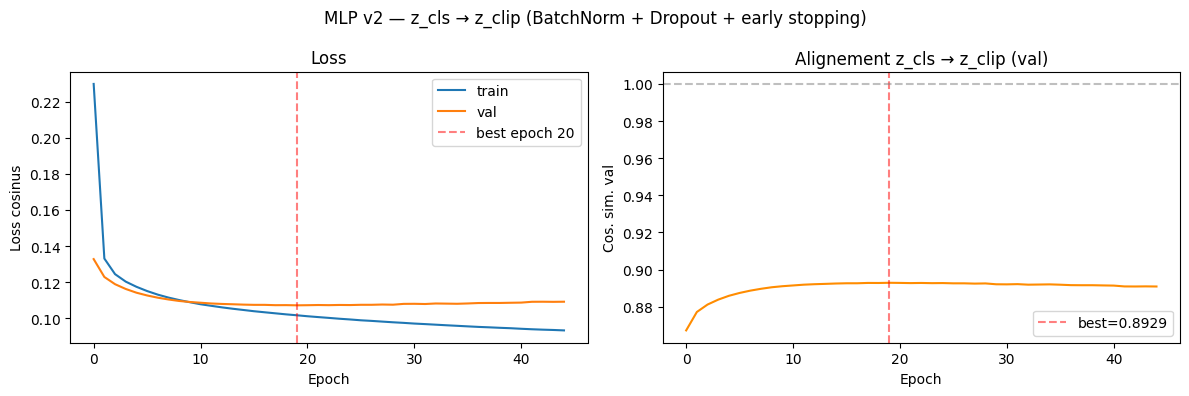

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MLP v2 — z_cls → z_clip (BatchNorm + Dropout + early stopping)')

axes[0].plot(history_v2['train_loss'], label='train')
axes[0].plot(history_v2['val_loss'], label='val')
axes[0].axvline(best_epoch_v2 - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch_v2}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss cosinus')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_v2['val_cos_sim'], color='darkorange')
axes[1].axvline(best_epoch_v2 - 1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos_v2:.4f}')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cos. sim. val')
axes[1].set_title('Alignement z_cls → z_clip (val)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4.6 Comparaison z_full vs z_cls

In [15]:
print('=' * 50)
print('Comparaison finale — val cosine similarity')
print('=' * 50)
print(f'z_full  baseline (wp3_2) : 0.8894')
print(f'z_full  v2       (wp3_3) : 0.8898')
print(f'z_cls   baseline         : {best_cos_baseline_cls:.4f}')
print(f'z_cls   v2               : {best_cos_v2:.4f}')
print('=' * 50)

Comparaison finale — val cosine similarity
z_full  baseline (wp3_2) : 0.8894
z_full  v2       (wp3_3) : 0.8898
z_cls   baseline         : 0.8925
z_cls   v2               : 0.8929


## 4.7 Test zero-shot (z_cls v2)

In [16]:
import json
import os
from transformers import CLIPProcessor, CLIPModel

try:
    clip_model
    print('CLIP deja en memoire')
except NameError:
    CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'
    clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
    clip_model.eval()
    print('CLIP recharge')

model_cls_v2.load_state_dict(torch.load('projection_cls_mlpv2_best.pt'))
model_cls_v2.eval()

norm_stats = torch.load('z_cls_norm_stats.pt')
z_mean = norm_stats['mean']
z_std = norm_stats['std']

with open('imagenet100-hf/label2text.json') as f:
    label2text = json.load(f)
CONCEPTS = [f'a photo of a {name}' for name in label2text.values()]

text_inputs = clip_processor(text=CONCEPTS, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
      text_out = clip_model.text_model(**text_inputs)
      text_features = clip_model.text_projection(text_out.pooler_output)
text_features = F.normalize(text_features.float(), dim=-1)

N_SAMPLES = 10
z_cls_samples = data_val['z_cls'][:N_SAMPLES]
z_clip_samples = data_val['z_clip'][:N_SAMPLES]
labels_samples = data_val['labels'][:N_SAMPLES]

z_cls_norm = (z_cls_samples - z_mean) / z_std
with torch.no_grad():
    z_proj = model_cls_v2(z_cls_norm.to(DEVICE))

sims_proj = z_proj @ text_features.T
sims_clip = z_clip_samples.to(DEVICE) @ text_features.T

TOP_K = 3
correct_top1 = 0
print(f'\n{"="*60}')
for i in range(N_SAMPLES):
    true_idx = labels_samples[i].item()
    true_name = label2text[str(true_idx)]
    top_proj_idx = sims_proj[i].topk(TOP_K).indices.tolist()
    top_clip_idx = sims_clip[i].topk(TOP_K).indices.tolist()
    pred_names = [label2text[str(j)] for j in top_proj_idx]
    oracle_names = [label2text[str(j)] for j in top_clip_idx]
    match = (true_idx == top_proj_idx[0])
    if match:
        correct_top1 += 1
    print(f'Sample {i+1} — Vraie classe : {true_name}')
    print(f'  z_cls MLP top-{TOP_K}: {pred_names}  {"OK" if match else "X"}')
    print(f'  CLIP oracle  top-{TOP_K}: {oracle_names}')
    print()

print(f'Top-1 accuracy sur {N_SAMPLES} exemples : {correct_top1}/{N_SAMPLES}')
print(f'(ref. z_full v2 : 4/10)')

CLIP deja en memoire

Sample 1 — Vraie classe : white stork
  z_cls MLP top-3: ['drake', 'spoonbill', 'pelican']  X
  CLIP oracle  top-3: ['white stork', 'bustard', 'crane']

Sample 2 — Vraie classe : rooster
  z_cls MLP top-3: ['rooster', 'drake', 'hen']  OK
  CLIP oracle  top-3: ['rooster', 'hen', 'drake']

Sample 3 — Vraie classe : bald eagle
  z_cls MLP top-3: ['drake', 'kite', 'terrapin']  X
  CLIP oracle  top-3: ['bald eagle', 'drake', 'American coot']

Sample 4 — Vraie classe : vine snake
  z_cls MLP top-3: ['vine snake', 'green snake', 'green mamba']  OK
  CLIP oracle  top-3: ['vine snake', 'green snake', 'green mamba']

Sample 5 — Vraie classe : flatworm
  z_cls MLP top-3: ['drake', 'electric ray', 'rock crab']  X
  CLIP oracle  top-3: ['flatworm', 'sea slug', 'electric ray']

Sample 6 — Vraie classe : green lizard
  z_cls MLP top-3: ['green lizard', 'common iguana', 'agama']  OK
  CLIP oracle  top-3: ['green lizard', 'common iguana', 'green mamba']

Sample 7 — Vraie classe : 